<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/17_GradientBoosting_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Boosting (Regresion)

## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestion de librerias
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split

#Escalar Variables
from sklearn.preprocessing import MinMaxScaler

#Configuracion de hiperparámetros
from sklearn.model_selection import ParameterGrid, GridSearchCV

#Creación de modelo
from sklearn.ensemble import GradientBoostingRegressor

# Evaluación del modelo
from sklearn.metrics import classification_report

#Creación de modelo
from sklearn.svm import SVR

#Evaluación del modelo
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             median_absolute_error)

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/mrbedoya/ml-2026/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = '01_carDetailsV4_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_REGRESION_PATH = os.path.join(MODELS_PATH, 'regresion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
# Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_REGRESION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/datasets/01_carDetailsV4_Prep.csv
dataset descargado exitosamente a: datasets/01_carDetailsV4_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/mrbedoya/ml-2026/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [6]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
#sys.path.append(UTILS_PATH)

## Importar Funciones externas
#from funciones import multiple_plot

## 3. Carga del dataset

In [7]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d=pd.read_csv(local_dataset_path)

In [8]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               1441 non-null   float64
 1   Year                1441 non-null   float64
 2   Kilometer           1441 non-null   float64
 3   Engine              1441 non-null   float64
 4   Length              1441 non-null   float64
 5   Width               1441 non-null   float64
 6   Height              1441 non-null   float64
 7   Seating Capacity    1441 non-null   float64
 8   Fuel Tank Capacity  1441 non-null   float64
 9   Fuel Type           1441 non-null   object 
 10  Transmission        1441 non-null   object 
 11  Owner               1441 non-null   object 
 12  Seller Type         1441 non-null   object 
 13  Drivetrain          1441 non-null   object 
 14  PriceRange          1441 non-null   int64  
dtypes: float64(9), int64(1), object(5)
memory usage: 169.0+

## 4. Visualización de datos

### Variables de entrada

In [9]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,Fuel Type,Transmission,Owner,Seller Type,Drivetrain
0,Petrol,Automatic,First,Individual,FWD
1,Diesel,Automatic,First,Corporate,AWD


In [10]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','float64','int32','int64']).columns.tolist()
d[numCols].head(2)

,Price,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,PriceRange
0,9540.0,2021.0,9000.0,1199.0,3993.0,1677.0,1532.0,5.0,35.0,1
1,10500.0,2014.0,99000.0,2199.0,4690.0,1880.0,1690.0,7.0,64.0,1


In [11]:
##Visualización de frecuencia de instancias para variables categóricas
#multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

In [12]:
#Visualización por medio de gráficos de caja de bigotes para las variables categóricas con respecto al precio
#multiple_plot(3, d , catCols, 'Price', 'boxplot', 'Distribución de la variable Make vs. el Price',30)

In [13]:
#Visualización de variables numéricas con respecto al precio
#multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

In [14]:
#Eliminar la variable de salida de la lista de variable numéricas
numCols.remove('Price')

### Variable de salida

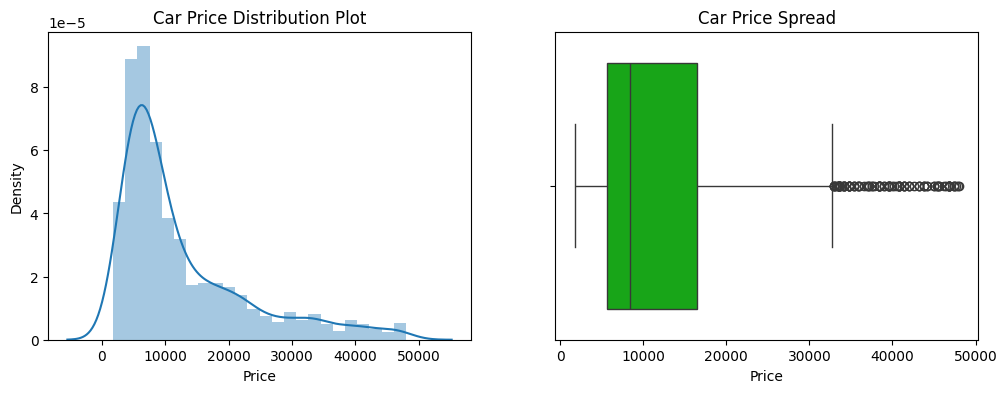

In [15]:
#Histográma y caja de bigotes del precio de los vehículos

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Car Price Distribution Plot')
sns.distplot(d.Price)

plt.subplot(1,2,2)
plt.title('Car Price Spread')
sns.boxplot(x=d.Price, palette='nipy_spectral')

plt.show()

In [16]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)

print(d.Price.describe(percentiles = [0.25,0.50,0.75,0.85,0.90,0.95,0.975,1]))

count    1441
mean    12601
std     10255
min      1740
25%      5580
50%      8388
75%     16500
85%     22500
90%     28800
95%     35880
97.5%   41400
100%    48000
max     48000
Name: Price, dtype: float64


## 5. Preparación de datos

### Creación de Variables Dummies

In [17]:
# Aplicación de la función de get_dummies

d =pd.get_dummies(d, drop_first=1)

In [18]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   1441 non-null   float64
 1   Year                    1441 non-null   float64
 2   Kilometer               1441 non-null   float64
 3   Engine                  1441 non-null   float64
 4   Length                  1441 non-null   float64
 5   Width                   1441 non-null   float64
 6   Height                  1441 non-null   float64
 7   Seating Capacity        1441 non-null   float64
 8   Fuel Tank Capacity      1441 non-null   float64
 9   PriceRange              1441 non-null   int64  
 10  Fuel Type_Otro          1441 non-null   bool   
 11  Fuel Type_Petrol        1441 non-null   bool   
 12  Transmission_Manual     1441 non-null   bool   
 13  Owner_Fourth            1441 non-null   bool   
 14  Owner_Second            1441 non-null   

## 6. Creación del modelo

### Dividir el conjunto de datos

In [19]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = d.drop(columns = "Price")
y = d['Price']

In [20]:
# División de los datos en train y test

#En este caso, el 80% de los datos se utilizarán para entrenar el modelo.

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

### Escalar Variables

In [21]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numerivas para posteriormente escalarlas
num_vars = numCols

print(num_vars)

['Year', 'Kilometer', 'Engine', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', 'PriceRange']


In [22]:
#Escalar Variables númericas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,Year,Kilometer,Engine,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,PriceRange
99,0.8235,0.4393,0.1016,0.1992,0.2613,0.3195,0.5000,0.2192,0.2000
1251,0.8235,0.3630,0.1044,0.3231,0.3814,0.2908,0.5000,0.1370,0.2000


### Creación del modelo

In [23]:
# Crear y entrenar el Gradient Boosting
model = GradientBoostingRegressor(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=1)

### Evaluación del modelo

In [24]:
# Error de test del modelo inicial
# ==============================================================================
predicciones = model.predict(X = X_test)

rmse = np.sqrt(mean_squared_error(y_true  = y_test, y_pred  = predicciones))
print(f"El error (rmse) de test es: {rmse}")

r2 = r2_score(y_test, predicciones)
print(f"El error (r2) de test es: {r2}")

El error (rmse) de test es: 2284.964893052054
El error (r2) de test es: 0.9475889436647108


## 7. Afinando el modelo (tuning)

### Preparacion de datos

In [25]:
#Nuevamente se asigna a 'X_Completo' y 'y_Completo' los datos entrada y salida respectivamente
X_Completo = X
y_Completo = y

#Se escalan los datos numéricos de entrada
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

In [26]:
# Guardar el scaler
joblib.dump(scaler, './modelos/scaler/minmaxFull_carDetailsV4.pkl')

['./modelos/scaler/minmaxFull_carDetailsV4.pkl']

### Identificando los mejores hiperparámetros

In [27]:
#Se entena el modelo con múltiples hiperparámetros buscando el mejor


# Definir el modelo GradientBoosting
modelGrdB = GradientBoostingRegressor()

CV = 10


# Definir los parámetros a ajustar y sus posibles valores
parameters = {
    'n_estimators': range(1, 100, 5),
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [3, 5, 7]
}



grid_GrdB = GridSearchCV(
        estimator  = modelGrdB,
        param_grid = parameters,
        n_jobs     = - 1,
        cv         = CV,
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid_GrdB.fit(X = X_Completo, y = y_Completo)

GridSearchCV(cv=10, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01, 0.001],
                         'max_depth': [3, 5, 7],
                         'n_estimators': range(1, 100, 5)},
             return_train_score=True)

In [28]:
# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid_GrdB.cv_results_)
resultados.filter(regex = '(param*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score
38,0.1000,5,91,0.9365,0.0169,0.9886,0.0007
36,0.1000,5,81,0.9361,0.0192,0.9876,0.0007
37,0.1000,5,86,0.9360,0.0182,0.9881,0.0007
39,0.1000,5,96,0.9360,0.0182,0.9890,0.0007


In [29]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)


# Obtener los resultados del grid search
results_grid_GrdB = pd.DataFrame(grid_GrdB.cv_results_)


# Seleccionar las columnas deseadas
columns_grid_GrdB = ['param_learning_rate']  + \
                    ['param_max_depth']  + \
                    ['param_n_estimators']  + \
                    ['mean_test_score', 'std_test_score']  + \
                    [f'split{i}_test_score' for i in range(CV)]

# Filtrar y mostrar los resultados
results_grid_GrdB_filtered = results_grid_GrdB[columns_grid_GrdB]

# Crear la columna scoreWithStd: f1 / std
results_grid_GrdB_filtered['scoreWithStd'] = results_grid_GrdB_filtered.apply(
    lambda row: row['mean_test_score'] / row['std_test_score'] if row['std_test_score'] != 0 else 0,
    axis=1
)

# Encuentra el índice del máximo valor en la columna scoreWithStd
indice_max_scoreWithStd = results_grid_GrdB_filtered['scoreWithStd'].idxmax()

# Mostrar los scores promedios por cada parámetro
results_grid_GrdB_filtered[['param_learning_rate', 'param_max_depth', 'param_n_estimators','mean_test_score', 'std_test_score', 'scoreWithStd']]


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,scoreWithStd
0,0.1000,3,1,0.1350,0.0090,14.9240
1,0.1000,3,6,0.5510,0.0315,17.4820
2,0.1000,3,11,0.7387,0.0372,19.8621
3,0.1000,3,16,0.8240,0.0326,25.2848
4,0.1000,3,21,0.8653,0.0289,29.9299
...,...,...,...,...,...,...
175,0.0010,7,76,0.1202,0.0093,12.8595
176,0.0010,7,81,0.1278,0.0096,13.2563
177,0.0010,7,86,0.1352,0.0100,13.5767
178,0.0010,7,91,0.1426,0.0105,13.6406


In [30]:
# Se identifican los mejores hiperparámetros
best_params = grid_GrdB.best_params_
print('Best Parameters : ',best_params)

Best Parameters :  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 91}


In [31]:
# Top 3 de los mejores scores
results_grid_GrdB_filtered.sort_values(by='scoreWithStd', ascending=False).head(3)[
    ['param_learning_rate', 'param_max_depth' ,'param_n_estimators','mean_test_score', 'std_test_score', 'scoreWithStd']]

,param_learning_rate,param_max_depth,param_n_estimators,mean_test_score,std_test_score,scoreWithStd
19,0.1000,3,96,0.9320,0.0159,58.4871
17,0.1000,3,86,0.9313,0.0160,58.0945
18,0.1000,3,91,0.9318,0.0162,57.3588


In [32]:
# Seleccionar el registro correspondiente al índice máximo
registro_max_scoreWithStd = results_grid_GrdB_filtered.loc[indice_max_scoreWithStd]

registro_max_scoreWithStd.transpose()

,19
param_learning_rate,0.1000
param_max_depth,3.0000
param_n_estimators,96.0000
mean_test_score,0.9320
std_test_score,0.0159
split0_test_score,0.9371
split1_test_score,0.9210
split2_test_score,0.9422
split3_test_score,0.9453
split4_test_score,0.9053


In [33]:
results_grid_GrdB_filtered.loc[indice_max_scoreWithStd]['mean_test_score']

np.float64(0.9320325697381465)

In [34]:
# Se crea un modelo árbol de decisión con los mejores hiperparámetros
modelGrdB = GradientBoostingRegressor(
                                        learning_rate = best_params["learning_rate"]
                                       , max_depth = best_params["max_depth"]
                                       , n_estimators = best_params["n_estimators"]
                                       , random_state = 1234)


#Se entrena el modelo con los datos completos
modelGrdB.fit(X_Completo, y_Completo)

GradientBoostingRegressor(max_depth=5, n_estimators=91, random_state=1234)

### Guardar modelo

In [35]:
#Se guarda el modelo de Gradient Boosting

MODEL_FILE_NAME = 'GBoostR_CV.pkl'
local_model_path = os.path.join(MODELS_REGRESION_PATH, MODEL_FILE_NAME)

joblib.dump(modelGrdB,  local_model_path)

['modelos/regresion/GBoostR_CV.pkl']

#### Referencias


- *Machine learning con Python y Scikit-learn:*
    - https://www.cienciadedatos.net/documentos/py06_machine_learning_python_scikitlearn.html
    

- *scikit-learn:*    
    - https://scikit-learn.org/stable/
    - https://scikit-learn.org/stable/user_guide.html
  
  
- *Gráficas con  seaborn:*
    - https://ichi.pro/es/como-utilizar-python-seaborn-para-analisis-de-datos-exploratorios-28897898172180





- *Analítica de grandes datos:*
    - https://jdvelasq.github.io/courses/analitica-de-grandes-datos/index.html